# Unbiased simulations

### Input:
* `data/ala2_solv.pdb`

### Output, for $n\in[0,\mathrm{num\_steps}]$:
* `workdir/step_n/traj.h5`
* `workdir/step_n/traj.out`
* `workdir/step_n/dihedrals.npy`
* `workdir/step_n/features.npy`

### Gather output into
* `workdir/dihedrals.npy`
* `workdir/features.npy`

## 1. Simulation parameters

In [1]:
import openmm.unit as unit
from src.param import param_unbiased_reference
from src.util import pretty_print

p = param_unbiased_reference()
# pretty_print(p)

## 2. Perform simulations and write dihedral & feature data

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
from openmm.app import Simulation, ForceField, PDBFile, HBonds

from src.data import simulation_data
from src.util import create_system, state_data_reporter, hdf5_reporter
from src.util import print_platform

step_start = 0
num_steps = 3000
do_simulation = False

if do_simulation:
    pdb = PDBFile(p.pdb_file)
    forcefield = ForceField("amber99sb.xml", "tip3p.xml")
    system = create_system(forcefield, pdb.topology)

    for step in range(step_start, num_steps):
        print(f"starting simulation {step} of {num_steps}")

        # start positions from 'sd' from previous step
        if step == 0:
            start_positions = pdb.positions
        else:
            if step == step_start:
                sd = simulation_data(p, subdir=(step - 1))
            start_positions = sd.final_positions
        assert (
            type(start_positions) == mm.unit.quantity.Quantity
        ), f"ERROR: {type(start_positions) = } in step {step}"

        # new 'sd' object for present simulation files
        sd = simulation_data(p, subdir=step)
        outfile = str(sd.files["outfile"])
        h5file = str(sd.files["h5file"])

        # each step requires new integrator, simulation object
        integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
        simulation = Simulation(pdb.topology, system, integrator)
        print_platform(simulation)
        simulation.context.setPositions(start_positions)
        sdr = state_data_reporter(outfile, p.report_interval)
        hdr = hdf5_reporter(h5file, p.report_interval)
        simulation.reporters.append(sdr)
        simulation.reporters.append(hdr)
        simulation.step(round(p.simulation_time / p.timestep))

        for reporter in simulation.reporters:
            if hasattr(reporter, "close"):
                reporter.close()

        # save 'final_positions'
        r = simulation.context.getState(getPositions=True).getPositions()
        sd.save_and_assign_objects({"final_positions": r})

        # calculate and save 'dihedrals', 'features' from 'h5file'
        sd.save_feature_data(recalculate=True)

## 3. Gather data from steps into master files

* Concatenate `dihedrals`, `features` arrays from each step
* Write combined data files to `p.working_dir`

sd.dihedrals.shape = (3000000, 2)
sd.features.shape = (3000000, 45)


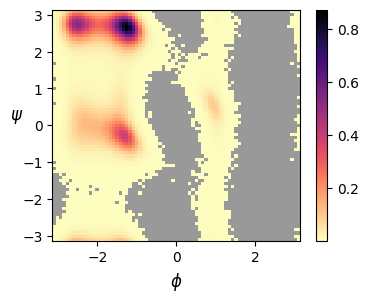

In [8]:
def plot_dihedrals_hist2d(fig, ax, dihedrals, weights=None, label=""):
    """Parameters:
    -----------
    dihedrals : array with shape (num_fraces, 2)
    weights : array with shape (num_frames,)
    label : str
        In case you want to place text on the plot
    pos : list-like (x, y)
        Location of label, if there is one
    """
    h = ax.hist2d(
        *dihedrals.T, bins=75, weights=weights, density=True, cmin=1e-10, cmap="magma_r"
    )
    fig.colorbar(h[3], ax=ax)
    ax.patch.set_facecolor("0.6")
    ax.set_xlabel(r"$\phi$", fontsize=12)
    ax.set_ylabel(r"$\psi$", fontsize=12, rotation=0)
    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([-np.pi, np.pi])
    if label:
        if len(label) < 8:
            pos = (1, -2.5)
        else:
            pos = (-0.5, -2.5)
        ax.text(*pos, label, fontsize=12)


gather_data = False
if gather_data:
    dihedrals, features = [], []
    for step in range(num_steps):
        sd = simulation_data(p, subdir=step)
        dihedrals.append(sd.dihedrals)
        features.append(sd.features)

    sd = simulation_data(p)
    sd.save_and_assign_objects(
        {"dihedrals": np.vstack(dihedrals), "features": np.vstack(features)}
    )
else:
    sd = simulation_data(p)

print(f"{sd.dihedrals.shape = }")
print(f"{sd.features.shape = }")
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plot_dihedrals_hist2d(fig, ax, sd.dihedrals)
fig.savefig("notes/figures/dihedral-hist2d.png", bbox_inches="tight")

## 4. Create tar file on `Backup Plus` and clean up

From `data/unbiased`:
```bash
$ make_tar.py /run/media/bharland/Backup\ Plus/Backup/ unbiased_june_2026.tar
$ rm -r step_*
```